# In Class May 19

In [20]:
# importing libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Importing the data

In [21]:
# importing mnist data from keras
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


### Visualizing the data

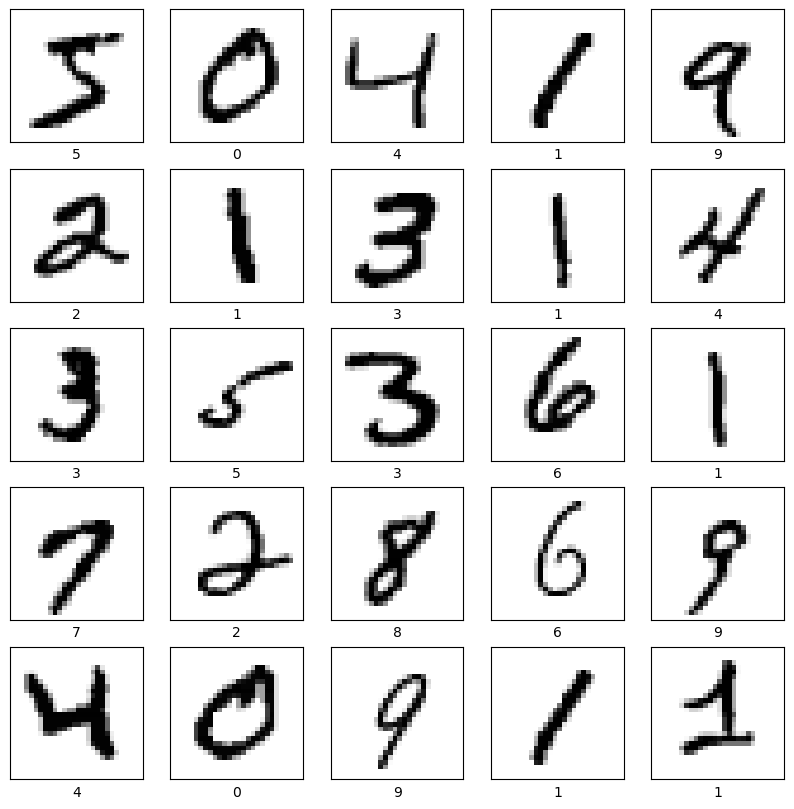

In [22]:
# visualize some of the data
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

### Preprocessing data for MLP

In [23]:
# Normalize pixel values to 0–1
X_train_norm = X_train / 255.0   # scale pixel values from 0–255 → 0–1
X_test_norm = X_test / 255.0     # apply same scaling to test data

# Flatten images for the MLP
X_train_flat = X_train_norm.reshape(X_train.shape[0], -1)  # # reshape from (60000, 28, 28) → (60000, 784)
X_test_flat = X_test_norm.reshape(X_test.shape[0], -1)     # same transformation for test images

print(X_train_flat.shape)
print(X_test_flat.shape)

(60000, 784)
(10000, 784)


### Building the MLP model

In [24]:
# Define the MLP model
mlp_model = keras.Sequential([
    layers.Input(shape=(784,)),                 # input is a flattened image (784 pixels)
    layers.Dense(128, activation="relu"),       # hidden layer with 128 neurons (learns patterns)
    layers.Dense(64, activation="relu"),        # second hidden layer for more complex patterns
    layers.Dense(10, activation="softmax"),     # output layer (10 classes for digits 0–9)
])

# Compile the MLP model
mlp_model.compile(
    optimizer="adam",                           # optimization algorithm for training
    loss="sparse_categorical_crossentropy",     # loss for multi-class classification with integer labels
    metrics=["accuracy"]                        # track accuracy during training
)

# summary of the MLP model architecture
mlp_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# train the MLP model
history_mlp = mlp_model.fit(
    X_train_flat,                               # flattened training images
    y_train,                                    # labels (0–9)
    epochs=5,                                   # number of training passes through data
    batch_size=128,                             # number of samples per training step
    validation_split=0.1                        # use 10% of training data for validation
)

# evaluate the MLP model on test data
test_loss_mlp, test_acc_mlp = mlp_model.evaluate(X_test_flat, y_test, verbose=2)
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8989 - loss: 0.3607 - val_accuracy: 0.9627 - val_loss: 0.1419
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9556 - loss: 0.1517 - val_accuracy: 0.9663 - val_loss: 0.1180
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9676 - loss: 0.1075 - val_accuracy: 0.9732 - val_loss: 0.0934
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9759 - loss: 0.0799 - val_accuracy: 0.9717 - val_loss: 0.1009
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9809 - loss: 0.0635 - val_accuracy: 0.9762 - val_loss: 0.0911
313/313 - 1s - 2ms/step - accuracy: 0.9718 - loss: 0.0875
MLP Test accuracy: 0.9718


### Preparing data for CNN

In [26]:
X_train_cnn = X_train_norm[..., np.newaxis]  # add channel dimension → (60000, 28, 28, 1)
X_test_cnn = X_test_norm[..., np.newaxis]    # same for test data

print("CNN input shape:", X_train_cnn.shape)  # confirm new shape for CNN

CNN input shape: (60000, 28, 28, 1)


### Building the CNN model

In [27]:
# define the model

cnn_model = models.Sequential([
    layers.Input(shape=(28,28,1)),                # input is 28x28 image with 1 channel (grayscale)
    layers.Conv2D(32, (3,3), activation="relu"),  # apply 32 filters to detect local patterns (edges, curves)
    layers.MaxPooling2D((2,2)),                   # reduce spatial size (summarize important features)
    layers.Flatten(),                             # convert feature maps into a vector
    layers.Dense(64, activation="relu"),          # combine extracted features into higher-level patterns
    layers.Dense(10, activation="softmax"),       # output probabilities for digits 0–9
])

In [28]:
# compile the model
cnn_model.compile(
    optimizer="adam",                             # optimization algorithm
    loss="sparse_categorical_crossentropy",       # loss for multi-class classification
    metrics=["accuracy"]                          # track accuracy during training
)

# train the model
cnn_history = cnn_model.fit(
    X_train_cnn,                                  # image data with spatial structure
    y_train,                                      # labels (correct digits)
    epochs=5,                                     # number of passes through the dataset
    validation_split=0.1                          # use 10% of training data for validation
)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9450 - loss: 0.1876 - val_accuracy: 0.9828 - val_loss: 0.0680
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9811 - loss: 0.0628 - val_accuracy: 0.9855 - val_loss: 0.0520
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9872 - loss: 0.0411 - val_accuracy: 0.9850 - val_loss: 0.0587
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9911 - loss: 0.0284 - val_accuracy: 0.9858 - val_loss: 0.0554
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9932 - loss: 0.0204 - val_accuracy: 0.9888 - val_loss: 0.0498


### Evaluating the CNN model

In [29]:
# Evaluate the CNN on test data
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test)  # evaluate on unseen test data
print("CNN Test Accuracy:", cnn_acc)                        # report final test accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9857 - loss: 0.0460
CNN Test Accuracy: 0.9857000112533569


### MLP vs CNN model

In [30]:
# Compare the CNN's performance to the MLP baseline
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")
print(f"CNN Test accuracy: {cnn_acc:.4f}")                      


MLP Test accuracy: 0.9718
CNN Test accuracy: 0.9857


### Visualizing model training

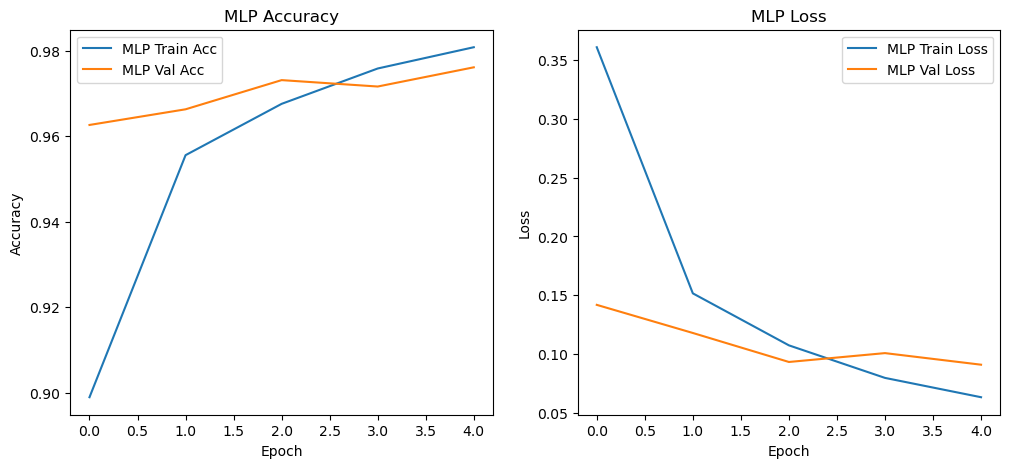

In [31]:
# Plot training history for MLP (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_mlp.history['accuracy'], label='MLP Train Acc')
plt.plot(history_mlp.history['val_accuracy'], label='MLP Val Acc')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mlp.history['loss'], label='MLP Train Loss')
plt.plot(history_mlp.history['val_loss'], label='MLP Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


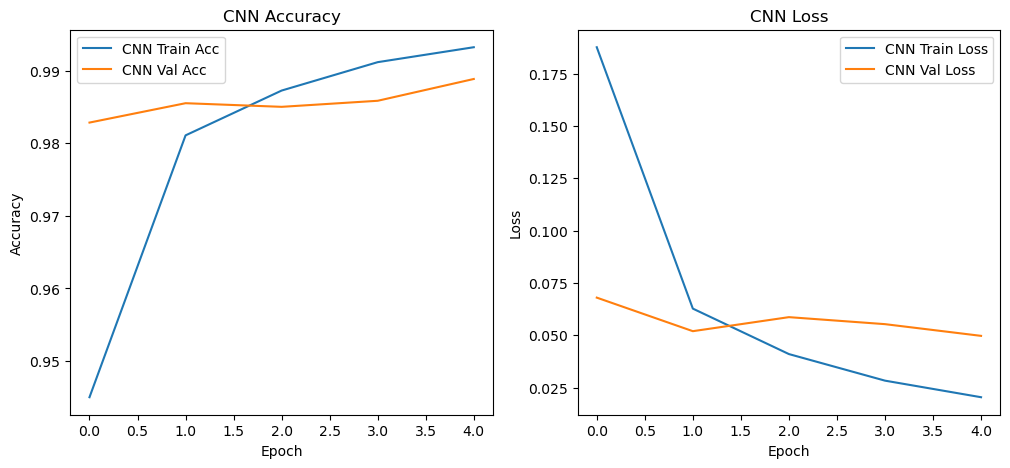

In [32]:
# plot training history for CNN (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


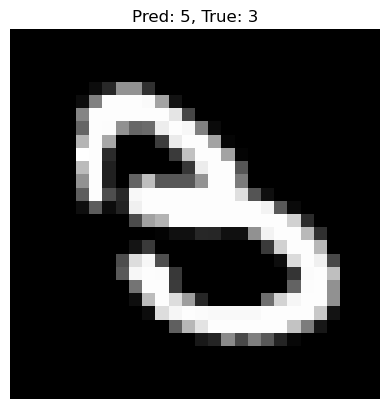

In [33]:
# Get predictions
cnn_predictions = cnn_model.predict(X_test_cnn)

# Find a misclassified example
for i in range(len(X_test)):
    pred = np.argmax(cnn_predictions[i])  # predicted class

    if pred != y_test[i]:                 # compare to true label
        plt.imshow(X_test[i], cmap="gray")
        plt.title(f"Pred: {pred}, True: {y_test[i]}")
        plt.axis("off")
        break

### How well do the models perform if we rotate the images?

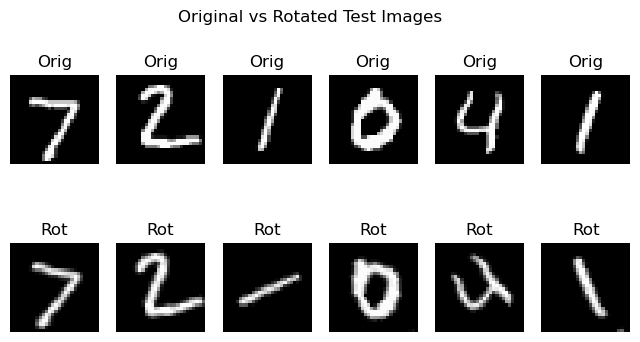

In [34]:
# Visualize rotated test images (to see what changed)

rotation_layer_eval = tf.keras.layers.RandomRotation(0.15)

X_test_rot_eval_cnn = rotation_layer_eval(X_test_cnn, training=True)

plt.figure(figsize=(8, 4))

for i in range(6):
    # Original
    plt.subplot(2, 6, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title("Orig")
    plt.axis('off')

    # Rotated
    plt.subplot(2, 6, i + 7)
    plt.imshow(X_test_rot_eval_cnn[i].numpy().squeeze(), cmap='gray')
    plt.title("Rot")
    plt.axis('off')

plt.suptitle("Original vs Rotated Test Images")
plt.show()

In [35]:
# Flatten rotated images for MLP
X_test_rot_eval_flat = X_test_rot_eval_cnn.numpy().reshape(X_test.shape[0], -1)

# Evaluate original models on rotated data
mlp_rot_eval_loss, mlp_rot_eval_acc = mlp_model.evaluate(X_test_rot_eval_flat, y_test)
cnn_rot_eval_loss, cnn_rot_eval_acc = cnn_model.evaluate(X_test_rot_eval_cnn, y_test)

print("MLP accuracy (original test):", test_acc_mlp)
print("MLP accuracy (rotated test):", mlp_rot_eval_acc)

print("CNN accuracy (original test):", cnn_acc)
print("CNN accuracy (rotated test):", cnn_rot_eval_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7026 - loss: 1.4243
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7731 - loss: 1.1525
MLP accuracy (original test): 0.9718000292778015
MLP accuracy (rotated test): 0.7026000022888184
CNN accuracy (original test): 0.9857000112533569
CNN accuracy (rotated test): 0.7731000185012817


### New models trained with data augmentation (random rotations)

In [36]:
# Create rotated datasets for retraining models
rotation_layer_train = tf.keras.layers.RandomRotation(0.15)

X_train_rot_train_cnn = rotation_layer_train(X_train_cnn, training=True)  # rotated training images for CNN
X_test_rot_train_cnn = rotation_layer_train(X_test_cnn, training=True)    # rotated test images for CNN

# Flatten rotated datasets for MLP
X_train_rot_train_flat = X_train_rot_train_cnn.numpy().reshape(X_train.shape[0], -1)
X_test_rot_train_flat = X_test_rot_train_cnn.numpy().reshape(X_test.shape[0], -1)

### Use the code cell below to build, train and evaluate an MLP model using the rotated data (X_train_rot_train_flat and X_test_rot_train_flat)

In [37]:
# Define the MLP model (same architecture as before)
mlp_rot_model = keras.Sequential([
    layers.Input(shape=(784,)),                 # input is a flattened image (784 pixels)
    layers.Dense(128, activation="relu"),       # hidden layer with 128 neurons
    layers.Dense(64, activation="relu"),        # second hidden layer
    layers.Dense(10, activation="softmax"),     # output layer (10 classes for digits 0–9)
])

# Compile the model
mlp_rot_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train on rotated training data
history_mlp_rot = mlp_rot_model.fit(
    X_train_rot_train_flat,                     # rotated + flattened training images
    y_train,                                    # labels (0–9)
    epochs=5,                                   # same number of epochs as original MLP
    batch_size=128,
    validation_split=0.1
)

# Evaluate on rotated test data
mlp_rot_loss, mlp_rot_acc = mlp_rot_model.evaluate(X_test_rot_train_flat, y_test, verbose=2)
print(f"MLP (rotated) Test accuracy: {mlp_rot_acc:.4f}")

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8284 - loss: 0.5801 - val_accuracy: 0.9238 - val_loss: 0.2591
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9179 - loss: 0.2751 - val_accuracy: 0.9403 - val_loss: 0.1956
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9385 - loss: 0.2053 - val_accuracy: 0.9480 - val_loss: 0.1803
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9505 - loss: 0.1643 - val_accuracy: 0.9570 - val_loss: 0.1499
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9570 - loss: 0.1386 - val_accuracy: 0.9537 - val_loss: 0.1530
313/313 - 1s - 2ms/step - accuracy: 0.9484 - loss: 0.1808
MLP (rotated) Test accuracy: 0.9484


### Use the code cell below to build, train and evaluate a CNN model using the rotated data (X_train_rot_train_cnn and X_test_rot_train_cnn)

In [38]:
# Define the CNN model (same architecture as before)
cnn_rot_model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),              # input is 28x28 grayscale image
    layers.Conv2D(32, (3, 3), activation="relu"), # 32 filters to detect local patterns
    layers.MaxPooling2D((2, 2)),                  # reduce spatial size
    layers.Flatten(),                             # convert feature maps to a vector
    layers.Dense(64, activation="relu"),          # combine extracted features
    layers.Dense(10, activation="softmax"),       # output probabilities for digits 0–9
])

# Compile the model
cnn_rot_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train on rotated training data
history_cnn_rot = cnn_rot_model.fit(
    X_train_rot_train_cnn,                        # rotated training images (with channel dim)
    y_train,                                      # labels (0–9)
    epochs=5,                                     # same number of epochs as original CNN
    validation_split=0.1
)

# Evaluate on rotated test data
cnn_rot_loss, cnn_rot_acc = cnn_rot_model.evaluate(X_test_rot_train_cnn, y_test, verbose=2)
print(f"CNN (rotated) Test accuracy: {cnn_rot_acc:.4f}")

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.8906 - loss: 0.3584 - val_accuracy: 0.9593 - val_loss: 0.1372
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9541 - loss: 0.1511 - val_accuracy: 0.9690 - val_loss: 0.1102
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9653 - loss: 0.1098 - val_accuracy: 0.9737 - val_loss: 0.0978
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9726 - loss: 0.0862 - val_accuracy: 0.9748 - val_loss: 0.0910
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9787 - loss: 0.0674 - val_accuracy: 0.9752 - val_loss: 0.0838
313/313 - 1s - 3ms/step - accuracy: 0.9701 - loss: 0.0909
CNN (rotated) Test accuracy: 0.9701


### Using the markdown cell below evaluate the performance of the MLP vs the CNN. Use graphs and metrics to support your evaluation.

         Model  Test Accuracy  Test Loss
MLP (original)         0.9718   0.087525
CNN (original)         0.9857   0.045987
 MLP (rotated)         0.9484   0.180814
 CNN (rotated)         0.9701   0.090884


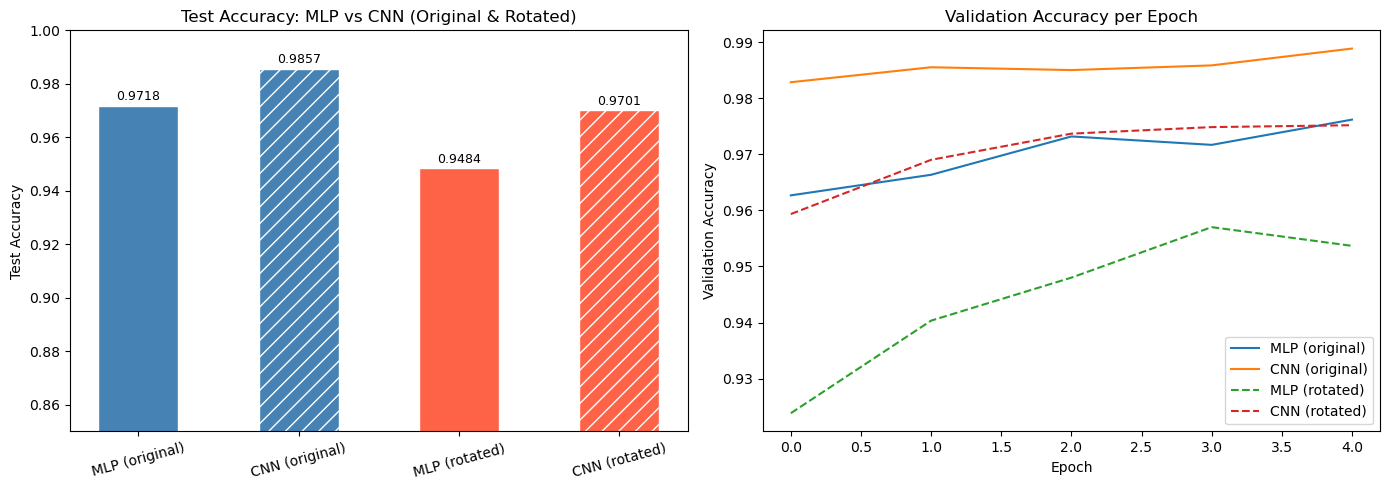

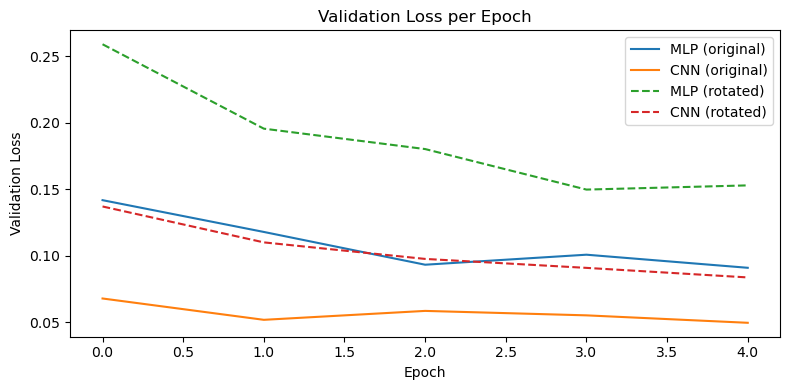

In [39]:
# ── 1. Summary metrics table ──────────────────────────────────────────────────
results = pd.DataFrame({
    "Model":        ["MLP (original)", "CNN (original)", "MLP (rotated)", "CNN (rotated)"],
    "Test Accuracy": [test_acc_mlp,     cnn_acc,          mlp_rot_acc,     cnn_rot_acc],
    "Test Loss":     [test_loss_mlp,    cnn_loss,         mlp_rot_loss,    cnn_rot_loss],
})
print(results.to_string(index=False))

# ── 2. Bar chart: accuracy comparison ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["steelblue", "steelblue", "tomato", "tomato"]
hatches = ["", "//", "", "//"]
bars = axes[0].bar(results["Model"], results["Test Accuracy"],
                   color=colors, hatch=hatches, edgecolor="white", width=0.5)
axes[0].set_ylim(0.85, 1.0)
axes[0].set_ylabel("Test Accuracy")
axes[0].set_title("Test Accuracy: MLP vs CNN (Original & Rotated)")
axes[0].tick_params(axis="x", rotation=15)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.001,
                 f"{bar.get_height():.4f}",
                 ha="center", va="bottom", fontsize=9)

# ── 3. Training accuracy curves (all 4 models) ───────────────────────────────
for hist, label, ls in [
    (history_mlp,     "MLP (original)",  "-"),
    (cnn_history,     "CNN (original)",  "-"),
    (history_mlp_rot, "MLP (rotated)",   "--"),
    (history_cnn_rot, "CNN (rotated)",   "--"),
]:
    axes[1].plot(hist.history["val_accuracy"], linestyle=ls, label=label)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy")
axes[1].set_title("Validation Accuracy per Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

# ── 4. Training loss curves (all 4 models) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for hist, label, ls in [
    (history_mlp,     "MLP (original)",  "-"),
    (cnn_history,     "CNN (original)",  "-"),
    (history_mlp_rot, "MLP (rotated)",   "--"),
    (history_cnn_rot, "CNN (rotated)",   "--"),
]:
    ax.plot(hist.history["val_loss"], linestyle=ls, label=label)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Loss")
ax.set_title("Validation Loss per Epoch")
ax.legend()
plt.tight_layout()
plt.show()

For the original images, the MLP reached 97.18% accuracy, while the CNN reached 98.57% accuracy. The CNN also had a lower loss, which shows it was making better predictions overall. The same pattern happened with the rotated images. The MLP reached 94.84% accuracy, but the CNN still did better at 97.01% accuracy. This shows that both models were affected by the harder rotated data, but the CNN handled it better. This makes sense because the CNN is designed for image data. It can learn patterns like edges, curves, and shapes while keeping the image structure. The MLP flattens the image into pixels, so it loses some of that spatial information.

Conclusion: The CNN is the stronger model for this task. The graphs and metrics show that it has better accuracy, lower loss, and handles rotated images better than the MLP.